In [65]:
import os
from dataclasses import dataclass
from typing import Tuple
import pytorch_lightning as pl
import pandas as pd
import torch
from IPython.display import display
from lightning.pytorch.loggers import CSVLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchmetrics.classification import BinaryAccuracy, BinaryROC
import numpy as np
from torch.utils.data import WeightedRandomSampler
import seaborn as sn
from torchmetrics.classification import BinaryConfusionMatrix

In [2]:
!nvidia-smi

Mon Oct 23 05:33:14 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 41%   30C    P8    15W / 140W |    777MiB / 16376MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 41%   

In [3]:
author_references = pd.read_hdf('author_references_sept27th_balanced.h5')

In [4]:
author_references

,@path,title,abstract,author,aff,author_first,author_last,@path2,title2,abstract2,author2,aff2,author_first2,author_last2,label
0,/0000-0002-6437-6176,A search for neutrino emission from the Fermi ...,Analysis of the Fermi-LAT data has revealed tw...,"James, C. W.","Erlangen Centre for Astroparticle Physics, Fri...",c,james,/0000-0002-6437-6176,The dispersion-brightness relation for fast ra...,Despite considerable efforts over the past dec...,"James, C. W.",International Centre for Radio Astronomy Resea...,c,james,True
1,/0000-0002-9619-2013,Kerr-Newman scalar clouds,Massive complex scalar fields can form bound s...,"Herdeiro, Carlos",Departamento de Física da Universidade de Avei...,c,herdeiro,/0000-0002-9619-2013,"Asymptotically flat scalar, Dirac and Proca st...","The existence of localized, approximately stat...","Herdeiro, Carlos A. R.",Departamento de Física da Universidade de Avei...,c,herdeiro,True
2,/0000-0001-6557-453X,Germanium nanowires sheathed with an oxide layer,We report how the structural arrangement of ge...,"Lee, C. S.",Center of Super-Diamond &amp; Advanced Films (...,c,lee,/0000-0001-6126-1333,Ionization Mechanism of Matrix-Assisted Laser ...,"In past studies, mistakes in determining the i...","Lee, Chuping","Institute of Atomic and Molecular Sciences, Ac...",c,lee,False
3,/0000-0001-8596-3583,Numerical simulation of global temperature cha...,The IAP/LASG GOALS coupled model is used to si...,"Yu, Yongqiang",State Key Laboratory of Numerical Modeling for...,y,yu,/0000-0002-2005-2778,Identification of atmospheric transport and di...,Backward trajectories of individual Asian dust...,"Yu, Yongjae","Department of Astronomy, Space Science, and Ge...",y,yu,False
4,/0000-0001-7296-4093,Deep in vivo photoacoustic imaging of mammalia...,Photoacoustic imaging allows absorption-based ...,"Cox, Ben",-,b,cox,/0000-0002-1571-1759,Mitochondrial and chloroplast genomes provide ...,Quinoa has recently gained international atten...,"Cox, Brian J.","Brigham Young University, Department of Plant ...",b,cox,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,/0000-0002-1443-7858,Integrable systems on a sphere as models for q...,Model potentials for quantum dots with smooth ...,"Salerno, Mario","Dipartimento di Scienze Fisiche, Università di...",m,salerno,/0000-0002-1443-7858,Matter-wave vortices and solitons in anisotrop...,"Using numerical methods, we construct families...","Salerno, Mario","Dipartimento di Fisica ""E.R. Caianiello"" and C...",m,salerno,True
24996,/0000-0002-1127-1661,The influence of mode coupling on the non-line...,On the basis of tearing mode theory a simple b...,"Coelho, R.","Associação EURATOM/IST, Instituto Superior Tec...",r,coelho,/0000-0002-1127-1661,Role of the shear flow profile on the stabilit...,Plasma flow affects the stability of a magneti...,"Coelho, R.","Japan Atomic Energy Research Institute, Naka 3...",r,coelho,True
24997,/0000-0002-8097-6913,Photoluminescence properties of a-(Si/SiN):H m...,We present new data on the luminescence decay ...,"Hopkinson, M.","Department of Physics, University of Sheffield...",m,hopkinson,/0000-0002-8097-6913,Photoluminescence decay time measurements from...,In this article we report the results of time ...,"Hopkinson, M.",EPSRC Central Facility for III-V Semiconductor...,m,hopkinson,True
24998,/0000-0003-0486-6023,Measurement of the hyperfine structure of anti...,Among the best measured quantities in physics ...,"Widmann, E.","Department of Physics, University of Tokyo, 7-...",e,widmann,/0000-0003-0486-6023,Sub-Doppler Two-Photon Laser Spectroscopy of A...,The ASACUSA collaboration of CERN has recently...,"Widmann, E.","Stefan Meyer Institut fü r Subatomare Physik, ...",e,widmann,True


In [5]:
@dataclass
class Config:
    """Configuration options for the Lightning MNIST example.

    Args:
        data_dir : The path to the directory where the MNIST dataset is stored. Defaults to the value of
            the 'PATH_DATASETS' environment variable or '.' if not set.

        save_dir : The path to the directory where the training logs will be saved. Defaults to 'logs/'.

        batch_size : The batch size to use during training. Defaults to 256 if a GPU is available,
            or 64 otherwise.

        max_epochs : The maximum number of epochs to train the model for. Defaults to 3.

        accelerator : The accelerator to use for training. Can be one of "cpu", "gpu", "tpu", "ipu", "auto".

        devices : The number of devices to use for training. Defaults to 1.

    Examples:
        This dataclass can be used to specify the configuration options for training a PyTorch Lightning model on the
        MNIST dataset. A new instance of this dataclass can be created as follows:

        >>> config = Config()

        The default values for each argument are shown in the documentation above. If desired, any of these values can be
        overridden when creating a new instance of the dataclass:

        >>> config = Config(batch_size=128, max_epochs=5)
    """

    #data_dir: str = os.environ.get("PATH_DATASETS", ".")
    save_dir: str = "logs/"
    #batch_size: int = 256 if torch.cuda.is_available() else 64
    #max_epochs: int = 3
    #accelerator: str = "auto"
    #devices: int = 1


config = Config()

In [6]:
@dataclass
class Config:
    data_dir: str = os.environ.get("PATH_DATASETS", ".")
    save_dir: str = "logs/"
    batch_size: int = 256 if torch.cuda.is_available() else 64
    max_epochs: int = 3
    accelerator: str = "auto"
    devices: int = 1
    num_layers: int = 3  # Number of layers in your neural network
    activation_function: str = "relu"  # Activation function to use (e.g., 'relu', 'sigmoid', etc.)
    num_neurons: int = 128  # Number of neurons in each layer

# Create an instance of the Config class
config = Config()


In [7]:
#aff1_chars2vec = np.concatenate((np.load('aff1_embeddings_1.npy'), np.load('aff1_embeddings_0.npy')), axis=0)
#aff2_chars2vec =  np.concatenate((np.load('aff2_embeddings_1.npy'), np.load('aff2_embeddings_0.npy')), axis=0)
aff1_chars2vec = np.load('aff1_embeddings.npy')
aff2_chars2vec = np.load('aff2_embeddings.npy')

In [8]:
#author1_chars2vec = np.concatenate((np.load('author1_embeddings_0.npy'), np.load('author1_embeddings_1.npy')), axis=0)
#author2_chars2vec = np.concatenate((np.load('author2_embeddings_0.npy'), np.load('author2_embeddings_1.npy')), axis=0)
author1_chars2vec = np.load('author1_embeddings.npy')
author2_chars2vec = np.load('author2_embeddings.npy')

In [9]:
author1_specter = torch.load('author1_embeddings_specter.pth', map_location='cpu')
author2_specter = torch.load('author2_embeddings_specter.pth', map_location='cpu')
author1_np_specter = author1_specter.detach().cpu().numpy()
author2_np_specter = author2_specter.detach().cpu().numpy()

In [10]:
# author1_specter = torch.cat([torch.load('author1_embeddings_1_specter.pth', map_location='cpu'),
#                              torch.load('author1_embeddings_2_specter.pth', map_location='cpu')], axis = 1)
# author2_specter = torch.cat([torch.load('author2_embeddings_1_specter.pth', map_location='cpu'),
#                              torch.load('author2_embeddings_2_specter.pth', map_location='cpu')], axis = 1)
# author1_np_specter = author1_specter.detach().cpu().numpy()
# author2_np_specter = author2_specter.detach().cpu().numpy()

In [11]:
!nvidia-smi

Mon Oct 23 05:33:16 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 41%   30C    P8    15W / 140W |    777MiB / 16376MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 41%   

In [12]:
import gc
torch.cuda.empty_cache()
gc.collect()

20

In [13]:
#device = author1_specter.device

In [14]:
# To load the embeddings back later, you can use torch.load
#author1_chars2vec = torch.tensor(author1_chars2vec, dtype=torch.float32).to(device)
#aff1_chars2vec = torch.tensor(aff1_chars2vec, dtype=torch.float32).to(device)
#author2_chars2vec = torch.tensor(author2_chars2vec, dtype=torch.float32).to(device)
#aff2_chars2vec = torch.tensor(aff2_chars2vec, dtype=torch.float32).to(device)

In [15]:
author1_embed = np.concatenate([author1_np_specter, author1_chars2vec,aff1_chars2vec], axis =1)
author2_embed = np.concatenate([author2_np_specter, author2_chars2vec,aff2_chars2vec], axis =1)

In [67]:
class ANDDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str = "path/to/dir", batch_size: int = 512):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.data =  TensorDataset(torch.cat([torch.unsqueeze(torch.tensor(author1_embed, dtype = torch.float32), axis = 1),
               torch.unsqueeze(torch.tensor(author2_embed, dtype = torch.float32), axis = 1)], axis = 1),
               torch.tensor(author_references.label.to_list(), dtype=torch.bool))
    def setup(self, stage: str):
        self.specter_train, self.specter_val, self.specter_test = random_split(self.data, [20000, 4500, 500])
        # Calculate class weights for weighted random sampler
        labels = [label.item() for _, label in self.specter_train]
        
        class_counts = torch.bincount(torch.tensor(labels, dtype=torch.int64))

        # Number of samples you want to sample
        num_samples = len(labels)

        # Weights for each sample
        weights = [1.0 / class_counts[i] for i in range(len(class_counts))]

        # List to contain the weights of each sample
        sample_weights = []

        for idx, label in enumerate(labels):
            class_weight = weights[label]
            sample_weights.append(class_weight)

        self.sampler = WeightedRandomSampler(sample_weights, num_samples)

    def train_dataloader(self):
        return DataLoader(self.specter_train, batch_size=self.batch_size, num_workers=0, sampler=self.sampler)

    def val_dataloader(self):
        return DataLoader(self.specter_val, batch_size=self.batch_size, num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.specter_test, batch_size=self.batch_size, num_workers=0)

In [68]:
# class ANDDataModule(pl.LightningDataModule):
#     def __init__(self, data_dir: str = "path/to/dir", batch_size: int = 512):
#         super().__init__()
#         self.data_dir = data_dir
#         self.batch_size = batch_size
#         self.data =  TensorDataset(torch.cat([torch.tensor(author1_embed, dtype = torch.float32),
#                torch.tensor(author2_embed, dtype = torch.float32)], axis = 1),
#                torch.tensor(author_references.label.to_list(), dtype=torch.bool))
#     def setup(self, stage: str):
#         self.specter_train, self.specter_val, self.specter_test = random_split(self.data, [20000, 4500, 500])
#         # Calculate class weights for weighted random sampler
#         labels = [label.item() for _, label in self.specter_train]
        
#         class_counts = torch.bincount(torch.tensor(labels, dtype=torch.int64))

#         # Number of samples you want to sample
#         num_samples = len(labels)

#         # Weights for each sample
#         weights = [1.0 / class_counts[i] for i in range(len(class_counts))]

#         # List to contain the weights of each sample
#         sample_weights = []

#         for idx, label in enumerate(labels):
#             class_weight = weights[label]
#             sample_weights.append(class_weight)

#         self.sampler = WeightedRandomSampler(sample_weights, num_samples)

#     def train_dataloader(self):
#         return DataLoader(self.specter_train, batch_size=self.batch_size, num_workers=0, sampler=self.sampler)

#     def val_dataloader(self):
#         return DataLoader(self.specter_val, batch_size=self.batch_size, num_workers=0)

#     def test_dataloader(self):
#         return DataLoader(self.specter_test, batch_size=self.batch_size, num_workers=0)

In [69]:
dataset = ANDDataModule()

In [70]:
#dataset.prepare_data()
dataset.setup(0)
loader = dataset.test_dataloader()
for tensor, label in iter(loader):
     print(tensor,label)

tensor([[[-0.2358, -0.9828,  0.0269,  ...,  0.6843,  0.7396,  0.2174],
         [-0.4590, -0.2834,  0.2660,  ...,  0.8203,  0.5259,  0.0168]],

        [[ 0.6466, -0.1274, -0.1194,  ...,  0.5552,  0.1267, -0.2175],
         [ 0.8460, -0.1228,  0.7843,  ...,  0.9550,  0.6150, -0.3128]],

        [[ 1.6387,  0.5501, -1.3963,  ...,  0.9498,  0.7433, -0.3698],
         [-0.1071, -0.4048,  0.8329,  ...,  0.7777,  0.6488, -0.5413]],

        ...,

        [[ 0.0952, -0.8614, -1.5745,  ...,  0.7312,  0.5667, -0.2148],
         [ 0.5276,  0.1150, -1.6603,  ...,  0.7712,  0.6664, -0.1808]],

        [[-0.3696,  0.3875,  0.0555,  ...,  0.6491,  0.7719, -0.5037],
         [-0.6490,  1.0607, -0.0767,  ...,  0.8407,  0.6517, -0.5358]],

        [[ 1.0794,  0.1080,  0.3389,  ...,  0.6524,  0.2339, -0.7384],
         [ 1.2028,  0.7475, -0.4749,  ...,  0.6454,  0.7506, -0.2526]]]) tensor([False, False, False, False, False,  True, False, False,  True,  True,
         True,  True, False,  True,  True,  

In [71]:
os.environ['TOKENIZERS_PARALLELISM'] = "False"

In [72]:
!nvidia-smi

Wed Oct 25 08:13:52 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 41%   43C    P2    38W / 140W |   4375MiB / 16376MiB |     11%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 59%   

In [166]:
class ANDismabiguator(pl.LightningModule): 
    
    def __init__(self,dropout_prob=0.375):
        super().__init__()
        self.l1 = nn.Sequential(nn.Linear(868, 1024),
                                nn.ReLU(),
                                nn.Dropout(dropout_prob), 
                                nn.Linear(1024, 256),
                                nn.ReLU(), 
                                nn.Dropout(dropout_prob), 
                                nn.Linear(256, 64), 
                                nn.Sigmoid())
        self.margin = 0.5
        self.accuracy = BinaryAccuracy(threshold = 0.7)
        self.BCELoss = nn.BCELoss() 
        self.CosineEmbeddingLoss = nn.CosineEmbeddingLoss(margin = self.margin)
        self.trainoutputs = {}
        self.valoutputs = {}
        self.bcm = BinaryConfusionMatrix()
        
    def forward(self, x):
        return self.l1(x)
    
    def ANDloss(self,batch):
        x, y = batch
        y_hat = self(x)
        sign = torch.where(y, torch.tensor(1), torch.tensor(-1))
        cosine_sim = torch.cosine_similarity(y_hat[:,0,:] , y_hat[:,1,:])
        loss = self.CosineEmbeddingLoss(y_hat[:,0,:] , y_hat[:,1,:] ,sign)
        accuracy = self.accuracy(torch.clamp(cosine_sim, min = 0, max = 1), y)
        total_loss = loss.mean() 
        self.trainoutputs = {'loss': loss, 'y': y, 'y_hat': y_hat, 'x': x, 'CS': cosine_sim, 'accuracy':accuracy}
        
        return accuracy, total_loss
    
    
    def training_step(self, batch, batch_idx):
        accuracy, loss = self.ANDloss(batch)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", accuracy, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        cosine_sim = torch.cosine_similarity(y_hat[:, 0, :], y_hat[:, 1, :])
        accuracy, loss = self.ANDloss(batch)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", accuracy, prog_bar=True)
        
        # Store misclassified data for later analysis
        self.valoutputs = {'loss': loss, 'y': y, 'y_hat':y_hat, 'CS': cosine_sim, 'x': x, 'accuracy': accuracy}
        return loss  

    def on_train_epoch_end(self):
        y = self.trainoutputs['y']
        y_hat = self.trainoutputs['y_hat']
        loss = self.trainoutputs['loss']
        CS = self.trainoutputs['CS']
        x = self.trainoutputs['x']
        accuracy = self.trainoutputs['accuracy']

        # Compute ROC using BinaryROC
        roc = BinaryROC()
        preds = CS  
        targets = y 
        fpr, tpr, thresholds = roc(preds, targets)

        # Calculate G-Mean for each threshold
        gmeans = torch.sqrt(tpr * (1 - fpr))

        # Find the optimal threshold
        index = torch.argmax(gmeans)
        optimal_threshold = thresholds[index]

        self.log("train_end_acc", tpr[index], prog_bar=True)
        self.log("train_end_threshold", optimal_threshold.item(), prog_bar=True)

        
    def on_val_epoch_end(self):
        y = self.valoutputs['y']
        y_hat = self.valoutputs['y_hat']
        loss = self.valoutputs['loss']
        CS = self.valoutputs['CS']
        x = self.valoutputs['x']
        accuracy = self.valoutputs['accuracy']

        # Compute ROC using BinaryROC
        roc = BinaryROC()
        preds = CS  
        targets = y 
        fpr, tpr, thresholds = roc(preds, targets)

        # Calculate G-Mean for each threshold
        gmeans = torch.sqrt(tpr * (1 - fpr))

        # Find the optimal threshold
        index = torch.argmax(gmeans)
        optimal_threshold = thresholds[index]

        self.log("val_end_acc", tpr[index], prog_bar=True)
        self.log("val_end_threshold", optimal_threshold.item(), prog_bar=True)
        
        # Collect misclassified data points
        misclassified_indices = (accuracy < optimal_threshold.item())  # Adjust the threshold as needed
        misclassified_samples = x[misclassified_indices]
        misclassified_labels = y[misclassified_indices]
        
        # Define the directory and file path to save misclassified samples
        save_dir = "misclassified_samples"
        os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist
        file_path = os.path.join(save_dir, f"misclassified_samples_epoch{self.current_epoch}.pt")
        
        # Save misclassified samples to a file
        torch.save({'samples': misclassified_samples, 'labels': misclassified_labels}, file_path)
        preds = torch.where(CS<optimal_threshold, torch.tensor(0), torch.tensor(1))
        print(self.bcm(preds, y))
        
    def test_step(self, batch, batch_idx):
        accuracy, loss = self.ANDloss(batch)
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", accuracy, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adamax(self.parameters(), lr=0.001, weight_decay=0.000001)

In [167]:
# class ANDClassifier(pl.LightningModule):
    
#     def __init__(self):
#         super().__init__()
#         self.l1 = nn.Sequential(nn.Linear(1736,1), nn.Sigmoid())
#         self.accuracy = BinaryAccuracy(threshold = 0.65)
        
#     def forward(self, x):
#         return self.l1(x)
    
#     def ANDloss(self,batch):
#         x, y = batch
#         y_hat = self(x)
        
#         # Assuming y_hat is your model's output for each example
#         criterion = nn.BCELoss()
#         loss = criterion(y_hat, y.unsqueeze(1).type(torch.float32))
        
#         accuracy = self.accuracy(y_hat, y.unsqueeze(1).type(torch.float32))  # You need to implement the accuracy function
#         return accuracy, loss

#     def on_validation_epoch_end(self):
#         y = self.outputs['y']
#         loss = self.outputs['loss']
#         y_hat = self.outputs['y_hat']

#         # Compute ROC using BinaryROC
#         roc = BinaryROC()
#         preds = y_hat  
#         targets = y.unsqueeze(1)
#         fpr, tpr, thresholds = roc(preds, targets)

#         # Calculate G-Mean for each threshold
#         gmeans = torch.sqrt(tpr * (1 - fpr))

#         # Find the optimal threshold
#         index = torch.argmax(gmeans)
#         optimal_threshold = thresholds[index]

#         self.log("val_end_acc", tpr[index], prog_bar=True)
#         self.log("val_end_threshold", optimal_threshold.item(), prog_bar=True)
    
#     def training_step(self, batch, batch_idx):
#         accuracy, loss = self.ANDloss(batch)
#         self.log("train_loss", loss, prog_bar=True)
#         self.log("train_acc", accuracy, prog_bar=True)
#         return loss
    
#     def validation_step(self, batch, batch_idx):
#         x, y = batch
#         y_hat = self(x)
#         accuracy, loss = self.ANDloss(batch)
#         self.log("val_loss", loss, prog_bar=True)
#         self.log("val_acc", accuracy, prog_bar=True)
#         self.outputs = {'loss': loss, 'y': y, 'y_hat': y_hat}
#         return loss
        
#     def test_step(self, batch, batch_idx):
#         # this is the test loop
#         accuracy, loss = self.ANDloss(batch)
#         self.log("test_loss", loss, prog_bar=True)
#         self.log("test_acc", accuracy, prog_bar=True)
#         return loss

#     def configure_optimizers(self):
#         return torch.optim.AdamW(self.parameters(), lr=0.0001)

In [168]:
dataset.setup(0)
train_loader = dataset.train_dataloader()
trainer = pl.Trainer(max_epochs=5000, logger=CSVLogger(save_dir=config.save_dir))
model = ANDismabiguator()

trainer.fit(model, dataset)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/2
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/2
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 2 processes
----------------------------------------------------------------------------------------------------

You are using a CUDA device ('NVIDIA RTX A4000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
LOCAL_RANK: 1 - CUDA_VISIBLE_DEVICES: [0,1]

  

Sanity Checking: 0it [00:00, ?it/s]

/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]

/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/result.py:433: PossibleUserWarning: It is recommended to use `self.log('val_loss', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
  warning_cache.warn(
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/result.py:433: PossibleUserWarning: It is recommended to use `self.log('val_acc', ..., sync_dist=True)` when logging on epoch level in distributed setting to accumulate the metric across devices.
  warning_cache.warn(


...

Epoch 4974: 100%|██████████| 20/20 [00:00<00:00, 27.28it/s, v_num=458, train_loss=0.0111, train_acc=0.978, val_loss=0.143, val_acc=0.755, train_end_acc=0.728, train_end_threshold=0.998] 
Validation: 0it [00:00, ?it/s]
Epoch 4975: 100%|██████████| 20/20 [00:00<00:00, 65.47it/s, v_num=458, train_loss=0.0129, train_acc=0.974, val_loss=0.142, val_acc=0.755, train_end_acc=0.739, train_end_threshold=0.992] 
Validation: 0it [00:00, ?it/s]
Epoch 4976: 100%|██████████| 20/20 [00:00<00:00, 65.56it/s, v_num=458, train_loss=0.00737, train_acc=0.985, val_loss=0.143, val_acc=0.753, train_end_acc=0.750, train_end_threshold=0.956]
Validation: 0it [00:00, ?it/s]
Epoch 4977: 100%|██████████| 20/20 [00:00<00:00, 55.97it/s, v_num=458, train_loss=0.0201, train_acc=0.960, val_loss=0.142, val_acc=0.754, train_end_acc=0.783, train_end_threshold=0.916] 
Validation: 0it [00:00, ?it/s]
Epoch 4978: 100%|██████████| 20/20 [00:00<00:00, 66.25it/s, v_num=458, train_loss=0.0113, train_acc=0.978, val_loss=0.142, val_a

Epoch 4984: 100%|██████████| 20/20 [00:00<00:00, 67.07it/s, v_num=458, train_loss=0.0136, train_acc=0.974, val_loss=0.140, val_acc=0.757, train_end_acc=0.761, train_end_threshold=0.959]
Validation: 0it [00:00, ?it/s]
Epoch 4985: 100%|██████████| 20/20 [00:00<00:00, 66.10it/s, v_num=458, train_loss=0.00934, train_acc=0.982, val_loss=0.139, val_acc=0.762, train_end_acc=0.793, train_end_threshold=0.888]
Validation: 0it [00:00, ?it/s]
Epoch 4986: 100%|██████████| 20/20 [00:00<00:00, 66.25it/s, v_num=458, train_loss=0.0102, train_acc=0.978, val_loss=0.141, val_acc=0.756, train_end_acc=0.815, train_end_threshold=0.919] 
Validation: 0it [00:00, ?it/s]
Epoch 4987: 100%|██████████| 20/20 [00:00<00:00, 55.81it/s, v_num=458, train_loss=0.0102, train_acc=0.982, val_loss=0.140, val_acc=0.759, train_end_acc=0.750, train_end_threshold=0.992] 
Validation: 0it [00:00, ?it/s]
Epoch 4988: 100%|██████████| 20/20 [00:00<00:00, 66.62it/s, v_num=458, train_loss=0.0148, train_acc=0.971, val_loss=0.140, val_ac

Epoch 4994: 100%|██████████| 20/20 [00:00<00:00, 66.13it/s, v_num=458, train_loss=0.0184, train_acc=0.963, val_loss=0.139, val_acc=0.760, train_end_acc=0.761, train_end_threshold=0.977] 
Validation: 0it [00:00, ?it/s]
Epoch 4995: 100%|██████████| 20/20 [00:00<00:00, 66.04it/s, v_num=458, train_loss=0.0185, train_acc=0.963, val_loss=0.139, val_acc=0.758, train_end_acc=0.761, train_end_threshold=0.984] 
Validation: 0it [00:00, ?it/s]
Epoch 4996: 100%|██████████| 20/20 [00:00<00:00, 67.20it/s, v_num=458, train_loss=0.00891, train_acc=0.985, val_loss=0.141, val_acc=0.759, train_end_acc=0.739, train_end_threshold=0.993]
Validation: 0it [00:00, ?it/s]
Epoch 4997: 100%|██████████| 20/20 [00:00<00:00, 56.92it/s, v_num=458, train_loss=0.0242, train_acc=0.952, val_loss=0.142, val_acc=0.759, train_end_acc=0.739, train_end_threshold=0.971] 
Validation: 0it [00:00, ?it/s]
Epoch 4998: 100%|██████████| 20/20 [00:00<00:00, 67.05it/s, v_num=458, train_loss=0.0125, train_acc=0.974, val_loss=0.140, val_a

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 4999: 100%|██████████| 20/20 [00:00<00:00, 29.61it/s, v_num=458, train_loss=0.0166, train_acc=0.967, val_loss=0.141, val_acc=0.759, train_end_acc=0.761, train_end_threshold=0.976]


In [25]:
!nvidia-smi

Mon Oct 23 05:34:21 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA RTX A4000    On   | 00000000:01:00.0 Off |                  Off |
| 41%   40C    P2    41W / 140W |    777MiB / 16376MiB |     15%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA RTX A4000    On   | 00000000:C1:00.0 Off |                  Off |
| 41%   

,val_loss,val_acc,train_end_acc,train_end_threshold,train_loss,train_acc
epoch,,,,,,
0,0.242425,0.514667,NaN,NaN,NaN,NaN
0,NaN,NaN,0.641304,0.994089,NaN,NaN
1,0.241315,0.514667,NaN,NaN,NaN,NaN
1,NaN,NaN,0.641304,0.984429,NaN,NaN
2,NaN,NaN,NaN,NaN,0.20185,0.679688


/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categ

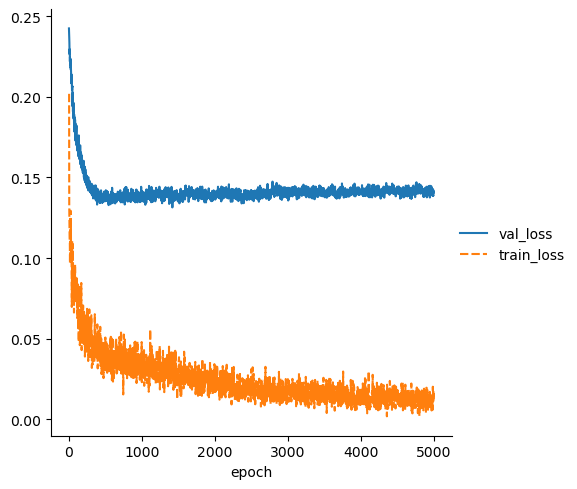

In [169]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_458/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_loss','train_loss']], kind="line")

,val_loss,val_acc,train_end_acc,train_end_threshold,train_loss,train_acc
epoch,,,,,,
0,0.242425,0.514667,NaN,NaN,NaN,NaN
0,NaN,NaN,0.641304,0.994089,NaN,NaN
1,0.241315,0.514667,NaN,NaN,NaN,NaN
1,NaN,NaN,0.641304,0.984429,NaN,NaN
2,NaN,NaN,NaN,NaN,0.20185,0.679688


/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categ

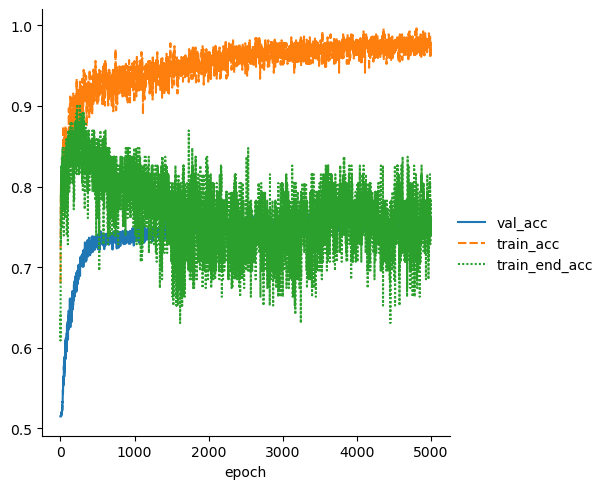

In [170]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_458/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_acc','train_acc','train_end_acc']], kind="line")

,val_loss,val_acc,val_end_acc,val_end_threshold,train_loss,train_acc
epoch,,,,,,
0,0.653936,0.505333,0.760417,0.536415,NaN,NaN
1,0.615458,0.551556,0.822917,0.545292,NaN,NaN
2,NaN,NaN,NaN,NaN,0.601565,0.603516
2,0.594054,0.528444,0.854167,0.442145,NaN,NaN
3,0.570625,0.620444,0.822917,0.502960,NaN,NaN


/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/vicenteamado/.conda/envs/pytorch_lightning/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categ

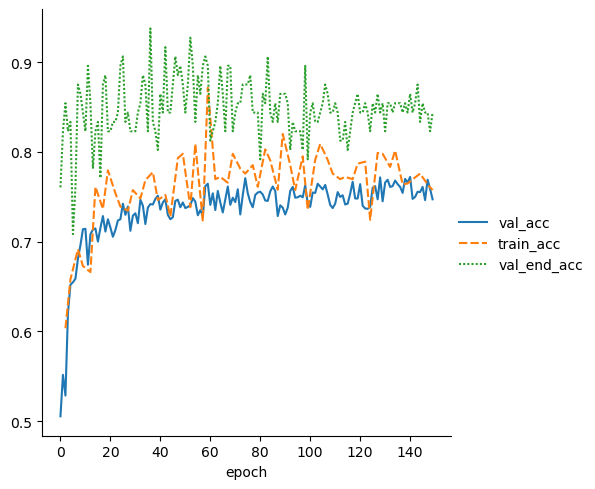

In [55]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_435/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_acc','train_acc','val_end_acc']], kind="line")

In [135]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_452/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_end_threshold']], kind="line")

,val_loss,val_acc,train_end_acc,train_end_threshold,train_loss,train_acc
epoch,,,,,,
0,0.243843,0.518222,NaN,NaN,NaN,NaN
0,NaN,NaN,0.504854,0.981108,NaN,NaN
1,0.234106,0.527111,NaN,NaN,NaN,NaN
1,NaN,NaN,0.592233,0.961476,NaN,NaN
2,NaN,NaN,NaN,NaN,0.226746,0.537109


KeyError: "None of [Index(['val_end_threshold'], dtype='object')] are in the [columns]"

In [ ]:
# Read in the training metrics from the CSV file generated by the logger
#metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")'logs/lightning_logs/version_2/metrics.csv'
metrics = pd.read_csv('logs/lightning_logs/version_452/metrics.csv')
# Remove the "step" column, which is not needed for our analysis
del metrics["step"]

# Set the epoch column as the index, for easier plotting
metrics.set_index("epoch", inplace=True)

# Display the first few rows of the metrics table, excluding any columns with all NaN values
display(metrics.dropna(axis=1, how="all").head())

# Create a line plot of the training metrics using Seaborn
sn.relplot(data=metrics[['val_end_threshold']], kind="line")

In [158]:
test_incorrect = torch.load('misclassified_samples/misclassified_samples_epoch99.pt', map_location='cpu')

In [159]:
test_incorrect

{'samples': tensor([[[[-0.1110, -1.9437,  0.6186,  ..., -0.2543,  0.1530, -0.3197],
           [ 0.8945,  0.7760,  0.0256,  ...,  0.9580,  0.2305,  0.2229]],
 
          [[ 0.5722, -0.6101, -0.6428,  ...,  0.6869,  0.6297, -0.7126],
           [ 0.0752,  1.4746, -0.5717,  ...,  0.7363,  0.5604, -0.7666]],
 
          [[-0.3838, -0.2315, -0.7461,  ...,  0.7752,  0.8149, -0.2364],
           [-0.2830, -0.4519, -0.5986,  ...,  0.7494,  0.7368, -0.3023]],
 
          ...,
 
          [[ 1.2886,  1.1579,  0.5637,  ...,  0.8112,  0.2741, -0.8293],
           [ 1.4811,  0.6916, -0.1533,  ...,  0.0704,  0.5146, -0.6772]],
 
          [[ 1.1911, -0.3970, -1.0696,  ..., -0.0205,  0.3249, -0.5580],
           [-0.2903,  0.6318, -0.3134,  ...,  0.3529,  0.2465, -0.6241]],
 
          [[ 0.9636,  0.6932, -0.5445,  ...,  0.6788,  0.1129, -0.7354],
           [ 0.5153,  0.3249,  0.3821,  ...,  0.9364,  0.5636, -0.7866]]]]),
 'labels': tensor([[ True,  True,  True, False, False,  True,  True,  True, F

In [160]:
incorrect_samples = test_incorrect['samples'][0]
full_samples =  TensorDataset(torch.cat([torch.unsqueeze(torch.tensor(author1_embed, dtype = torch.float32), axis = 1),
               torch.unsqueeze(torch.tensor(author2_embed, dtype = torch.float32), axis = 1)], axis = 1),
               torch.tensor(author_references.label.to_list(), dtype=torch.bool)).tensors[0]

In [161]:
matching_indexes = np.where(np.all(incorrect_samples.numpy()[:, np.newaxis] == full_samples.numpy(), axis=-1))

In [162]:
author_references.iloc[np.array(list(set(matching_indexes[0])))]

,@path,title,abstract,author,aff,author_first,author_last,@path2,title2,abstract2,author2,aff2,author_first2,author_last2,label
0,/0000-0002-6437-6176,A search for neutrino emission from the Fermi ...,Analysis of the Fermi-LAT data has revealed tw...,"James, C. W.","Erlangen Centre for Astroparticle Physics, Fri...",c,james,/0000-0002-6437-6176,The dispersion-brightness relation for fast ra...,Despite considerable efforts over the past dec...,"James, C. W.",International Centre for Radio Astronomy Resea...,c,james,True
1,/0000-0002-9619-2013,Kerr-Newman scalar clouds,Massive complex scalar fields can form bound s...,"Herdeiro, Carlos",Departamento de Física da Universidade de Avei...,c,herdeiro,/0000-0002-9619-2013,"Asymptotically flat scalar, Dirac and Proca st...","The existence of localized, approximately stat...","Herdeiro, Carlos A. R.",Departamento de Física da Universidade de Avei...,c,herdeiro,True
2,/0000-0001-6557-453X,Germanium nanowires sheathed with an oxide layer,We report how the structural arrangement of ge...,"Lee, C. S.",Center of Super-Diamond &amp; Advanced Films (...,c,lee,/0000-0001-6126-1333,Ionization Mechanism of Matrix-Assisted Laser ...,"In past studies, mistakes in determining the i...","Lee, Chuping","Institute of Atomic and Molecular Sciences, Ac...",c,lee,False
3,/0000-0001-8596-3583,Numerical simulation of global temperature cha...,The IAP/LASG GOALS coupled model is used to si...,"Yu, Yongqiang",State Key Laboratory of Numerical Modeling for...,y,yu,/0000-0002-2005-2778,Identification of atmospheric transport and di...,Backward trajectories of individual Asian dust...,"Yu, Yongjae","Department of Astronomy, Space Science, and Ge...",y,yu,False
4,/0000-0001-7296-4093,Deep in vivo photoacoustic imaging of mammalia...,Photoacoustic imaging allows absorption-based ...,"Cox, Ben",-,b,cox,/0000-0002-1571-1759,Mitochondrial and chloroplast genomes provide ...,Quinoa has recently gained international atten...,"Cox, Brian J.","Brigham Young University, Department of Plant ...",b,cox,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,/0000-0003-1658-1690,Constriction in a transpressive regime: an exa...,Detailed strain analyses in the Armorican quar...,"Dias, R.","Department Geologia, Faculdade Ciéncias, Unive...",r,dias,/0000-0002-5128-5531,Interplay between potential and spin-flip scat...,We study the behavior of a magnetic impurity i...,"Dias, R. G.","Department of Physics and I3N, University of A...",r,dias,False
198,/0000-0001-6271-0110,Small substorms: Solar wind input and magnetot...,We investigated properties of 43 small magneto...,"Baumjohann, W.",-,w,baumjohann,/0000-0001-6271-0110,Behavior of current sheets at directional magn...,Venus Express interplanetary magnetic field me...,"Baumjohann, W.","Space Research Institute, Austrian Academy of ...",w,baumjohann,True
199,/0000-0003-0473-1567,Cosmological structure formation with clusteri...,We study large-scale structure formation in th...,"Sefusatti, Emiliano","Institut de Physique Théorique, CEA, IPhT, and...",e,sefusatti,/0000-0003-0473-1567,The effect of local non-Gaussianity on the mat...,We compute the matter bispectrum in the presen...,"Sefusatti, E.","Institut de Physique Théorique, CEA and CNRS, ...",e,sefusatti,True
200,/0000-0001-7680-1056,Comparison of the use of first and second-orde...,We report on the use of second-order Raman amp...,"Frazão, O.",INESC TEC (Portugal),o,frazão,/0000-0001-7680-1056,Simultaneous strain and temperature measure ba...,In this work a simultaneous strain and tempera...,"Frazão, O.",INESC Porto (Portugal),o,frazão,True


In [163]:
for i in author_references.iloc[np.array(list(set(matching_indexes[0])))].iterrows():
    print(i[1]['abstract'])
    print(i[1]['author'])
    print(i[1]['abstract2'])
    print(i[1]['author2'])
    print(i[1]['label'])

Analysis of the Fermi-LAT data has revealed two extended structures above and below the Galactic Centre emitting gamma rays with a hard spectrum, the so-called Fermi bubbles. Hadronic models attempting to explain the origin of the Fermi bubbles predict the emission of high-energy neutrinos and gamma rays with similar fluxes. The ANTARES detector, a neutrino telescope located in the Mediterranean Sea, has a good visibility to the Fermi bubble regions. Using data collected from 2008 to 2011 no statistically significant excess of events is observed and therefore upper limits on the neutrino flux in TeV range from the Fermi bubbles are derived for various assumed energy cutoffs of the source.
James, C. W.
Despite considerable efforts over the past decade, only 34 fast radio bursts—intense bursts of radio emission from beyond our Galaxy—have been reported<SUP>1,2</SUP>. Attempts to understand the population as a whole have been hindered by the highly heterogeneous nature of the searches, wh

In [64]:
with open("output.txt", "w") as output_file:
    for i in author_references.iloc[np.array(list(set(matching_indexes[0])))].iterrows():
        output_file.write(i[1]['abstract'] + "\n")
        output_file.write(i[1]['author'] + "\n")
        output_file.write(i[1]['abstract2'] + "\n")
        output_file.write(i[1]['author2'] + "\n")
        output_file.write(str(i[1]['label']) + "\n")